<a href="https://colab.research.google.com/github/praveenkumarrlgmp-source/meachin-learing-project/blob/main/K_Nearest_Neighbors.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Shape: (270, 14)

Columns:
['Age', 'Sex', 'Chest pain type', 'BP', 'Cholesterol', 'FBS over 120', 'EKG results', 'Max HR', 'Exercise angina', 'ST depression', 'Slope of ST', 'Number of vessels fluro', 'Thallium', 'Heart Disease']

First 5 Rows:
   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2           

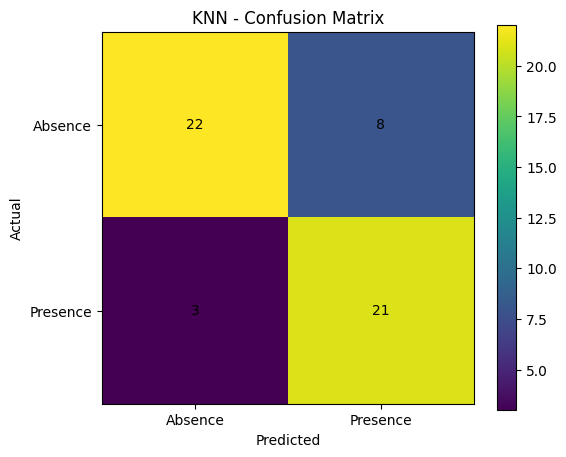

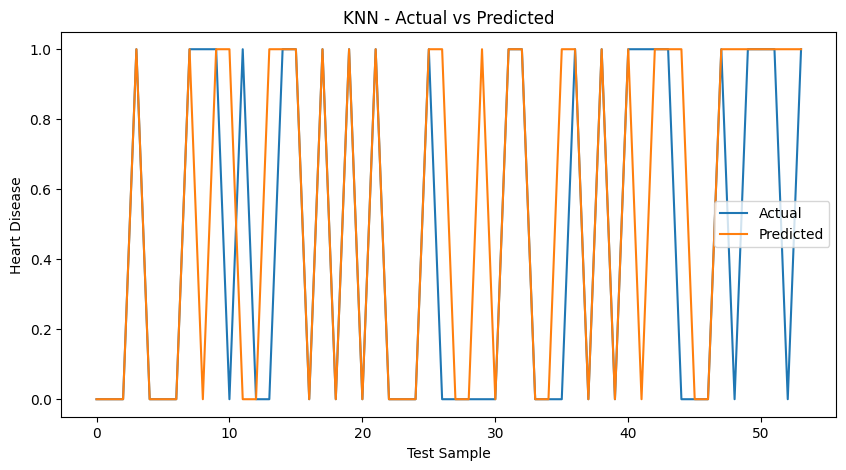

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1. LOAD DATASET
# ==========================================

df = pd.read_csv("Heart_Disease_Prediction.csv")

print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 Rows:")
print(df.head())


# ==========================================
# 2. CHECK MISSING VALUES
# ==========================================

print("\nMissing Values:")
print(df.isnull().sum())


# ==========================================
# 3. TARGET COLUMN
# ==========================================

# Target column in this dataset
target = "Heart Disease"

# Convert target into 0 and 1
df[target] = df[target].map({
    "Absence": 0,
    "Presence": 1
})


# ==========================================
# 4. SEPARATE X AND Y
# ==========================================

X = df.drop(target, axis=1)
y = df[target]


# ==========================================
# 5. CONVERT CATEGORICAL COLUMNS
# ==========================================

X = pd.get_dummies(
    X,
    drop_first=True
)


# ==========================================
# 6. TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# ==========================================
# 7. FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)


# ==========================================
# 8. CREATE KNN MODEL
# ==========================================

model = KNeighborsClassifier(
    n_neighbors=5
)


# ==========================================
# 9. TRAIN MODEL
# ==========================================

model.fit(
    X_train,
    y_train
)


# ==========================================
# 10. PREDICTION
# ==========================================

y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]


# ==========================================
# 11. EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    zero_division=0
)

roc_auc = roc_auc_score(
    y_test,
    y_prob
)


print("\n======================================")
print("KNN RESULTS")
print("======================================")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")


# ==========================================
# 12. CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

print("\nConfusion Matrix:")
print(cm)


# ==========================================
# 13. CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Absence",
            "Presence"
        ],
        zero_division=0
    )
)


# ==========================================
# 14. CONFUSION MATRIX GRAPH
# ==========================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("KNN - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.xticks(
    [0, 1],
    ["Absence", "Presence"]
)

plt.yticks(
    [0, 1],
    ["Absence", "Presence"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()


# ==========================================
# 15. ACTUAL VS PREDICTED GRAPH
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    y_pred,
    label="Predicted"
)

plt.xlabel("Test Sample")

plt.ylabel("Heart Disease")

plt.title(
    "KNN - Actual vs Predicted"
)

plt.legend()

plt.show()